In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
clean_df = pd.read_csv("../dataset/clean_aqi_data.csv")

clean_df.head()

,city,station,last_update,CO,NH3,NO2,OZONE,PM10,PM2.5,SO2
0,Agartala,"Bardowali, Agartala - Tripura SPCB",14-02-2025 17:00:00,24.0,10.000000,21.0,172.0,45.0,31.0,22.0
1,Agra,"Manoharpur, Agra - UPPCB",14-02-2025 17:00:00,7.0,1.000000,18.0,9.0,30.0,32.0,14.0
2,Agra,"Rohta, Agra - UPPCB",14-02-2025 17:00:00,25.0,4.000000,10.0,10.0,31.0,21.0,14.0
3,Agra,"Sanjay Palace, Agra - UPPCB",14-02-2025 17:00:00,40.0,6.178841,30.0,82.0,34.0,5.0,8.0
4,Agra,"Sector-3B Avas Vikas Colony, Agra - UPPCB",14-02-2025 17:00:00,24.0,2.000000,23.0,22.0,42.0,12.0,11.0


In [3]:
clean_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 494 entries, 0 to 493
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   city         494 non-null    object 
 1   station      494 non-null    object 
 2   last_update  494 non-null    object 
 3   CO           494 non-null    float64
 4   NH3          494 non-null    float64
 5   NO2          494 non-null    float64
 6   OZONE        494 non-null    float64
 7   PM10         494 non-null    float64
 8   PM2.5        494 non-null    float64
 9   SO2          494 non-null    float64
dtypes: float64(7), object(3)
memory usage: 38.7+ KB


In [4]:
clean_df.isnull().sum()

city           0
station        0
last_update    0
CO             0
NH3            0
NO2            0
OZONE          0
PM10           0
PM2.5          0
SO2            0
dtype: int64

In [5]:
clean_df.fillna(
    clean_df.mean(numeric_only=True),
    inplace=True
)

clean_df.isnull().sum()

city           0
station        0
last_update    0
CO             0
NH3            0
NO2            0
OZONE          0
PM10           0
PM2.5          0
SO2            0
dtype: int64

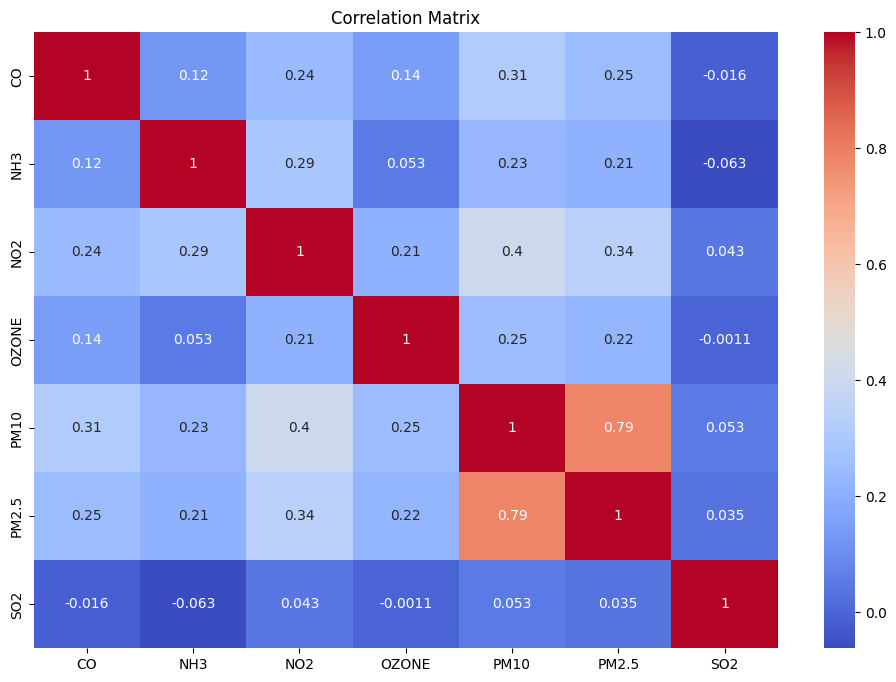

In [6]:
plt.figure(figsize=(12,8))

sns.heatmap(
    clean_df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Matrix")
plt.show()

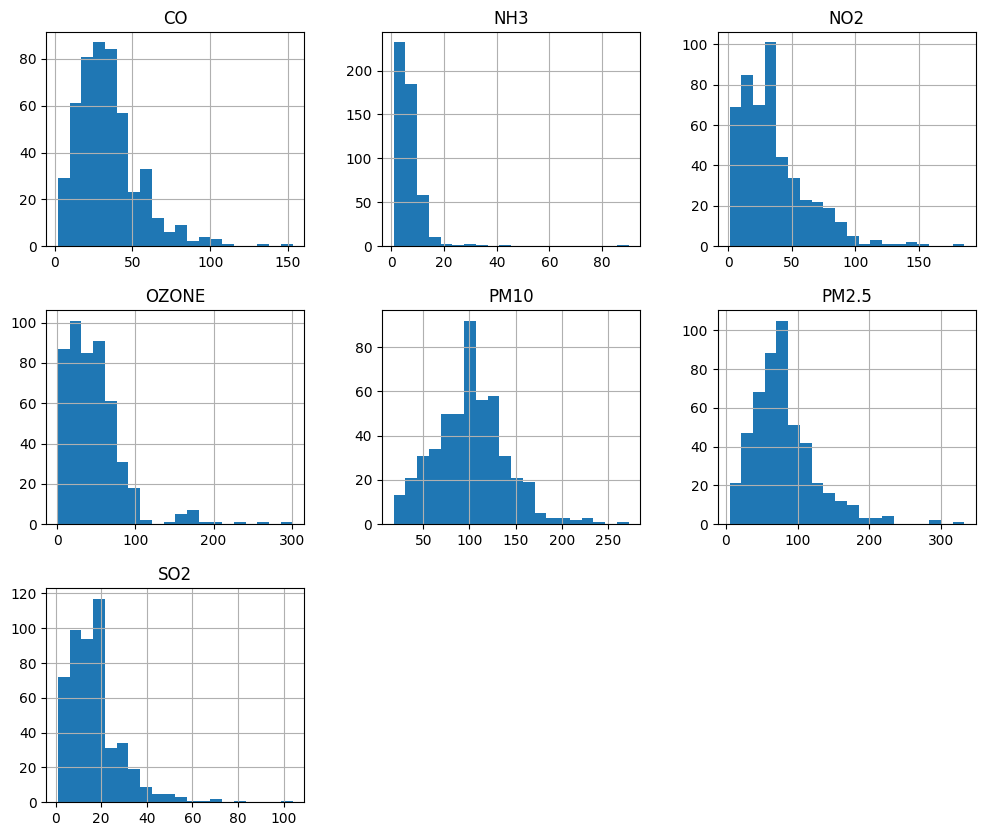

In [7]:
clean_df.hist(
    figsize=(12,10),
    bins=20
)

plt.show()

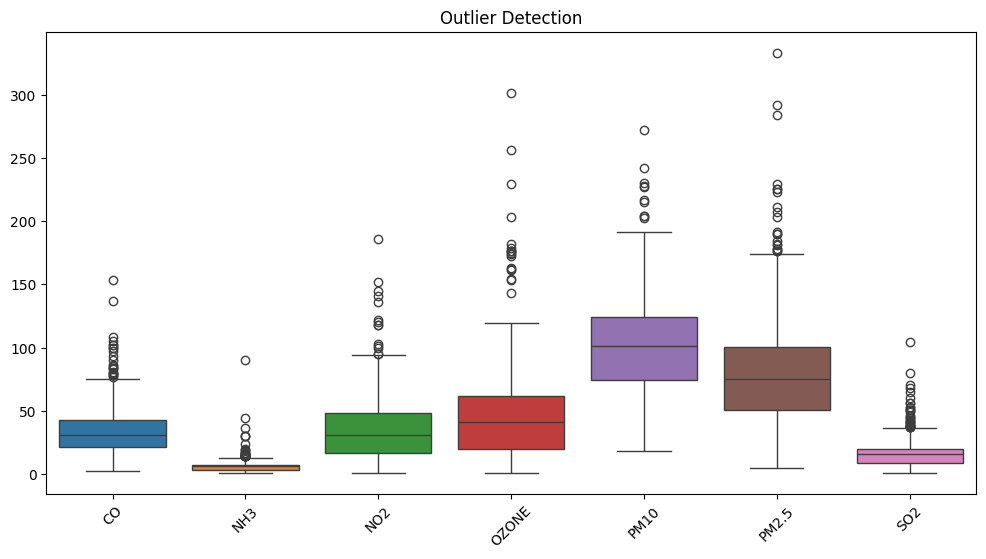

In [8]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=clean_df.select_dtypes(include='number')
)

plt.xticks(rotation=45)
plt.title("Outlier Detection")
plt.show()

In [9]:
# Features (Input)

X = clean_df[['CO', 'NH3', 'NO2', 'OZONE', 'PM10', 'SO2']]

# Target (Output)

y = clean_df['PM2.5']

print(X.head())
print(y.head())

     CO        NH3   NO2  OZONE  PM10   SO2
0  24.0  10.000000  21.0  172.0  45.0  22.0
1   7.0   1.000000  18.0    9.0  30.0  14.0
2  25.0   4.000000  10.0   10.0  31.0  14.0
3  40.0   6.178841  30.0   82.0  34.0   8.0
4  24.0   2.000000  23.0   22.0  42.0  11.0
0    31.0
1    32.0
2    21.0
3     5.0
4    12.0
Name: PM2.5, dtype: float64


In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (395, 6)
Testing Shape: (99, 6)


In [11]:
from sklearn.linear_model import LinearRegression

# Create Model

lr_model = LinearRegression()

# Train Model

lr_model.fit(X_train, y_train)

print("Linear Regression Model Trained Successfully!")

Linear Regression Model Trained Successfully!


In [12]:
lr_predictions = lr_model.predict(X_test)

print("Predictions:")
print(lr_predictions[:10])

Predictions:
[ 23.50170981  51.17884166 138.39523208  98.17441426  72.08330932
 129.44536293 119.51284222  89.35954446  19.93898176 118.497715  ]


In [13]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

print("Linear Regression Results")

print("MAE:",
      mean_absolute_error(y_test, lr_predictions))

print("MSE:",
      mean_squared_error(y_test, lr_predictions))

print("R2 Score:",
      r2_score(y_test, lr_predictions))

Linear Regression Results
MAE: 20.237850051062136
MSE: 730.6868969630544
R2 Score: 0.5823181495063885


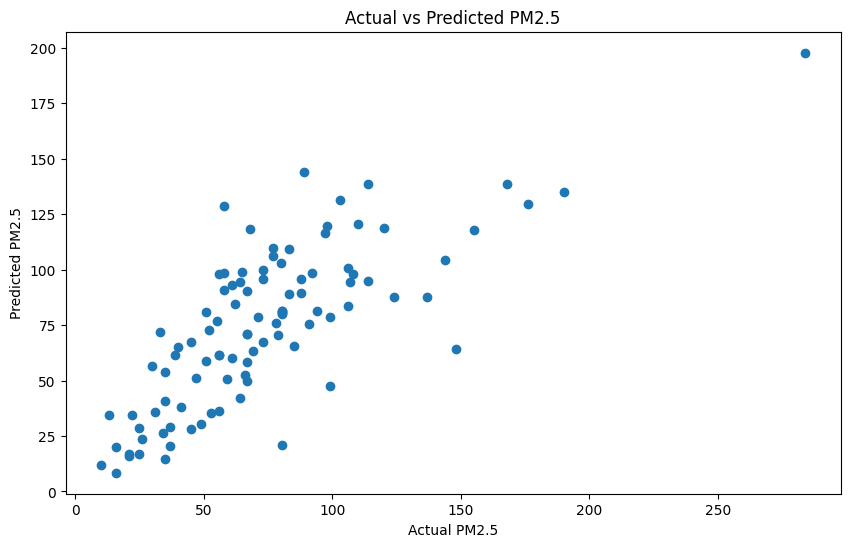

In [14]:
plt.figure(figsize=(10,6))

plt.scatter(y_test, lr_predictions)

plt.xlabel("Actual PM2.5")
plt.ylabel("Predicted PM2.5")

plt.title("Actual vs Predicted PM2.5")

plt.show()

In [15]:
from sklearn.ensemble import RandomForestRegressor

In [16]:
# Create Model

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

# Train Model

rf_model.fit(X_train, y_train)

print("Random Forest Model Trained Successfully!")

Random Forest Model Trained Successfully!


In [17]:
rf_predictions = rf_model.predict(X_test)

print("Random Forest Predictions:")
print(rf_predictions[:10])

Random Forest Predictions:
[ 41.48151316  49.36559211 155.27        98.00677632  67.98914474
 126.98       132.52032895  58.93        17.59       135.45151316]


In [18]:
print("Random Forest Results")

print("MAE:",
      mean_absolute_error(y_test, rf_predictions))

print("MSE:",
      mean_squared_error(y_test, rf_predictions))

print("R2 Score:",
      r2_score(y_test, rf_predictions))

Random Forest Results
MAE: 21.962715311004782
MSE: 848.5190617374403
R2 Score: 0.5149618621072425
